In [1]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import esmpy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
from scipy.spatial import KDTree
import datetime
from metpy.calc import wind_direction
from metpy.units import units
from matplotlib.font_manager import FontProperties
import string

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Coupled Simulation Results

**Table 1:** Detailed information about conducted simulations
| #  | Data Component | Input     | Temporal Interpolation Type | Coupling Type      | Feedback                 |
|----|----------------|-----------|-----------------------------|--------------------|--------------------------|
| r1 | CDEPS          | ERA5 (6h) | coszen                      | one-way: ATM->OCN  | No                       |
| r2 | CDEPS          | ERA5 (1h) | coszen                      | one-way: ATM->OCN  | No                       |
| r3 | CDEPS          | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r4 | CDEPS          | ERA5 (1h) | linear                      | one-way: ATM->OCN  | No                       |
| r5 | Aurora         | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r6 | Aurora         | ERA5 (6h) | linear                      | two-way: ATM<->OCN | Yes, SST from OCN to ATM |

In [2]:
# List of variables to keep
vars = {
    'Pair': [995, 1015],
    'Tair': [20, 28],
    'Uwind': [-5, 10],
    'Vwind': [0, 12],
    'swrad': [50, 200],
    'lwrad': [-25, 25],
    'latent': [-100, 100],
    'sensible': [-20, 100],
    'temp': [16, 26],
    'zeta' : [-0.2, 0.6]
}
var_names = list(vars.keys())

# Open datasets and merge them
# No shift means that the origianal ERA5 dataset not shifted in time
ds1 = xr.open_dataset("../run_cdeps/r1/irene_his.nc").isel(s_rho=-1)[var_names]
ds2 = xr.open_dataset("../run_cdeps/r2/irene_his.nc").isel(s_rho=-1)[var_names]
ds3 = xr.open_dataset("../run_cdeps/r3/irene_his.nc").isel(s_rho=-1)[var_names]
ds4 = xr.open_dataset("../run_cdeps/r4/irene_his.nc").isel(s_rho=-1)[var_names]
ds5 = xr.open_dataset("../run/r5/irene_his.nc").isel(s_rho=-1)[var_names]
ds6 = xr.open_dataset("../run/r6/irene_his.nc").isel(s_rho=-1)[var_names]
ds = xr.concat([ds1, ds2, ds3, ds4, ds5, ds6], dim='run_id')

# Load roms grid
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

In [3]:
ds

<xarray.Dataset> Size: 530MB
Dimensions:     (run_id: 6, ocean_time: 43, eta_rho: 106, xi_rho: 242)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 344B 2011-08-27T06:00:00 ... 2011...
    s_rho       float64 8B -0.0125
    lon_rho     (eta_rho, xi_rho) float64 205kB -75.19 -75.13 ... -64.62 -64.54
    lat_rho     (eta_rho, xi_rho) float64 205kB 32.24 32.28 ... 46.58 46.61
Dimensions without coordinates: run_id, eta_rho, xi_rho
Data variables:
    Pair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 990.3 ... nan
    Tair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 26.72 ... nan
    Uwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 20.51 ... nan
    Vwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 15.9 ... nan
    swrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.0 ... nan
    lwrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -9.085 ......
    latent      (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -245.4 ......
    sensible    (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -18.76 ......
    temp        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 27.04 ... nan
    zeta        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.4541 ......
Attributes: (12/33)
    file:              irene_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             Hurricane Irene, 27-29 Aug 2011
    var_info:          varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.27/ofi/gnu/9.1/bin/mpif90
    compiler_flags:    -I/glade/work/turuncu/ML/envs/spack-1.0.2/var/spack/en...
    tiling:            3x4
    history:           ROMS, Version 4.3, Thursday - January 15, 2026 - 12:56...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       IRENE, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, A...

In [4]:
ds_era5 = xr.open_dataset('era5_remap.nc')

### Compare Simulations

In [5]:
def add_gridlines(ax):
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

def add_features(ax, stock_img=True):
    ax.add_feature(cfeature.COASTLINE, alpha=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    if stock_img:
        ax.stock_img()

def add_roms_box(ax, grid):
    ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

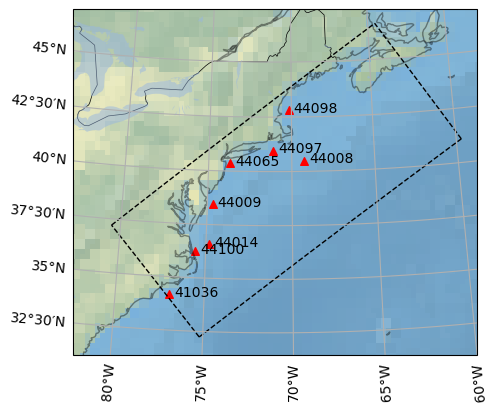

In [6]:
# Define bounding box limits
min_lat, max_lat = 31, 47
min_lon, max_lon = 278, 300

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
fig, ax = plt.subplots(1, 1,
    figsize=(12, 4), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Plot map
add_features(ax)
add_roms_box(ax, grid)
add_gridlines(ax)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Add observation locations
obs_loc = {
    "41036": [76.949, 34.207, "Onslow Bay Outer, NC", 0.3, -0.1, 'upper left'],
    "44009": [74.692, 38.460, "DELAWARE BAY 26 NM Southeast of Cape May, NJ", 0.3, -0.1, 'upper right'],
    "44065": [73.701, 40.368, "New York Harbor Entrance - 15 NM SE of Breezy Point , NY", 0.3, -0.1, 'lower left'],
    "44100": [75.593, 36.258, "Duck FRF 26m, NC (430)", 0.3, -0.1, 'upper left'],
    "44014": [74.837, 36.603, "VIRGINIA BEACH 64 NM East of Virginia Beach, VA", 0.3, -0.1, 'lower left'],
    "44097": [71.124, 40.967, "Block Island, RI (154)", 0.3, -0.1, 'lower left'],
    "44008": [69.254, 40.500, "NANTUCKET 54 NM Southeast of Nantucket", 0.3, -0.1, 'lower left'],
    "44098": [70.169, 42.800, "Jeffrey's Ledge, NH (160)", 0.3, -0.1, 'lower left'],
}

for key, val in obs_loc.items():
    lon = 360-val[0]
    lat = val[1]
    ax.scatter(lon, lat, marker='^', s=30, color='red', label=key, transform=ccrs.PlateCarree())
    ax.text(lon+val[3], lat+val[4], key, transform=ccrs.PlateCarree())

filename = "insitu_loc.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

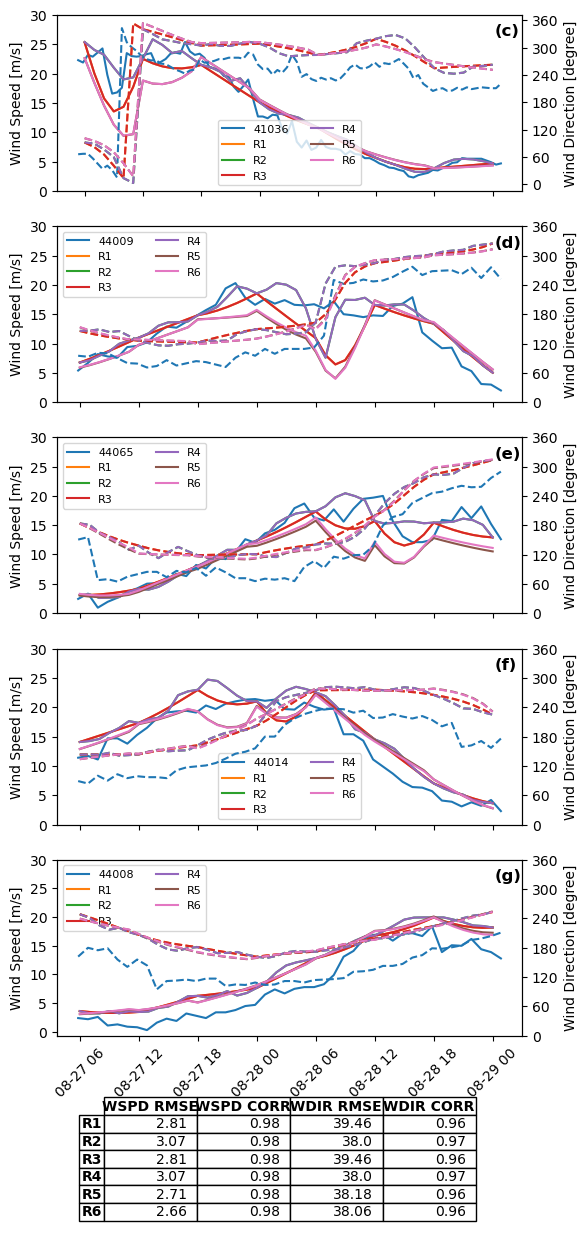

In [8]:
lowercase_letters = np.array(list(string.ascii_lowercase))

#fig, ax = plt.subplots(3, 2, figsize=(14,9))
fig, ax = plt.subplots(6, 1, figsize=(6,16))
ax_flat = ax.flatten()
h1 = datetime.timedelta(hours=1)
x = pd.to_datetime(ds.ocean_time)

# keep only wind stations
keep_keys = {"44065", "44008", "44009", "41036", "44014"}
obs_loc_wnd = {key: value for key, value in obs_loc.items() if key in keep_keys}

# Update label locations
obs_loc_wnd['41036'][5] = "lower center"
obs_loc_wnd['44008'][5] = "upper left"
obs_loc_wnd['44009'][5] = "upper left"
obs_loc_wnd['44065'][5] = "upper left"
obs_loc_wnd['44014'][5] = "lower center"

# Store statistics
stats_data = {}

indx = 0
for key, val in obs_loc_wnd.items():    
    # Read in observation
    df = pd.read_csv(f'data/{key}h2011.txt', sep='\\s+', skiprows = [1])
    df.columns = df.columns.str.replace('#', '')
    df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
    df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
    df = df[time_mask]
    df = df.set_index(df['Date'])
    df['WSPD'] = df['WSPD'].where(df['WSPD'] < 40.0)
    df['WDIR'] = df['WDIR'].where(df['WDIR'] >= 0.0)
    df['WDIR'] = df['WDIR'].where(df['WDIR'] <= 360.0)

    # Create new axis for y-axis in the right
    ax_flat_y = ax_flat[indx].twinx()

    # Plot observation, mask outliers or measurement errors
    ax_flat[indx].plot(df['Date'], df['WSPD'], label=f"{key}", )
    ax_flat_y.plot(df['Date'], df['WDIR'], label=f"{key}", linestyle='dashed')

    # Perform temporal interpolation to simulation time to calculate statistics
    new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
    df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[1:]

    # Find closest grid point for model data
    points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
    tree = KDTree(points)
    distance, index = tree.query([val[1], -1.0*val[0]])
    lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

    # Get model data and plot
    for id in ds.run_id.values:
        # Process data
        dataU = ds['Uwind'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
        dataV = ds['Vwind'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
        dataWSPD = np.sqrt(dataU*dataU+dataV*dataV)
        dataWDIR = wind_direction(dataU*units.m/units.s, dataV*units.m/units.s)
        # Calculate RMSE and correlation
        rmseWSPD = np.sqrt(np.mean((dataWSPD - df_interp['WSPD']).data ** 2))
        corrWSPD = np.corrcoef(dataWSPD, df_interp['WSPD'])[0, 1]
        # Use circular statistics for wind direction
        dataWDIR_rad = np.deg2rad(dataWDIR)
        obsWDIR_rad = np.deg2rad(df_interp['WDIR'])
        sinDiffWDIR = np.sin(dataWDIR_rad) - np.sin(obsWDIR_rad)
        cosDiffWDIR = np.cos(dataWDIR_rad) - np.cos(obsWDIR_rad)
        rmseWDIR_rad = np.sqrt(np.mean((sinDiffWDIR - cosDiffWDIR).data ** 2))
        rmseWDIR_deg = np.rad2deg(np.arctan2(rmseWDIR_rad, 1))
        corrWDIR = np.corrcoef(dataWDIR, df_interp['WDIR'])[0, 1]
        stats_data[f'R{id+1}'] = [rmseWSPD, corrWSPD, rmseWDIR_deg, corrWDIR]
        # Plot data
        ax_flat[indx].plot(x, dataWSPD, label=f'R{id+1}')
        ax_flat_y.plot(x, dataWDIR, label=f'R{id+1}', linestyle='dashed')

    # Set x-axis
    #ax_flat[indx].tick_params(axis='x', labelrotation=45)
    #ax_flat[indx].set_xlabel('Time [days]', fontsize=10)
    #if indx < 6: 
    #    ax_flat[indx].set_xticklabels([])
    #    ax_flat[indx].set_xlabel('')
    if indx == 4:
        ax_flat[indx].tick_params(axis='x', labelrotation=45)
        ax_flat[indx].set_xlabel('Time [days]', fontsize=10)
    else:
        ax_flat[indx].set_xticklabels([])
        ax_flat[indx].set_xlabel('')

    # Set y-axis
    ax_flat[indx].set_yticks(np.arange(0, 35, 5))
    ax_flat_y.set_yticks(np.arange(0, 361, 60))
    #if indx in [0, 2, 4]:
    #    ax_flat[indx].set_ylabel('Wind Speed [m/s]', fontsize=10)
    #else:
    #    ax_flat_y.set_ylabel('Wind Direction [degree]', fontsize=10)
    #if indx == 4:
    #    ax_flat_y.set_ylabel('Wind Direction [degree]', fontsize=10)
    ax_flat[indx].set_ylabel('Wind Speed [m/s]', fontsize=10)
    ax_flat_y.set_ylabel('Wind Direction [degree]', fontsize=10)

    # Add legend
    ax_flat[indx].legend(ncol=2, fontsize=8, loc=val[5])

    # Add label
    ax_flat[indx].text(0.94, 0.95, f'({lowercase_letters[indx+2]})', fontsize=12, fontweight='bold', verticalalignment='top', transform=ax_flat[indx].transAxes)

    indx = indx+1

# Add table
ax_flat[-1].axis('off')
ax_flat[-1].axis('tight')
df_table = pd.DataFrame(stats_data).round(2).T
df_table = df_table.rename(
    columns={
        0: 'WSPD RMSE',
        1: 'WSPD CORR',
        2: 'WDIR RMSE',
        3: 'WDIR CORR'
    }
)
table = pd.plotting.table(ax_flat[-1], df_table, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(0.8, 0.8)
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.1)
    if row == 0:
        cell.set_text_props(fontproperties=FontProperties(weight='bold'))
    if col == -1:
        cell.set_text_props(fontproperties=FontProperties(weight='bold'))

filename = "insitu_wind.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

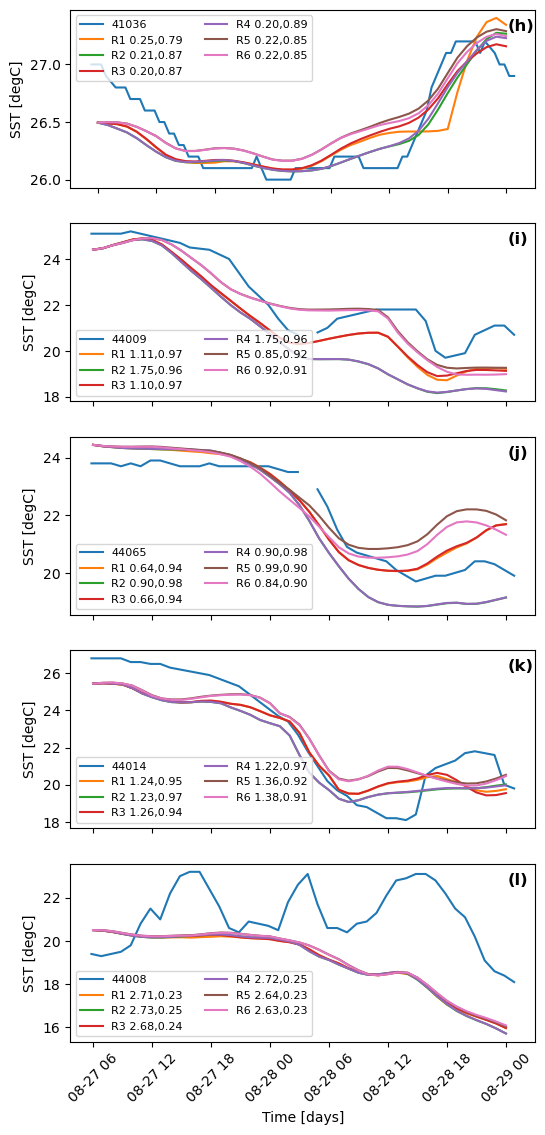

In [24]:
# keep only sst stations
keep_keys = {"44065", "44008", "44009", "41036", "44014"}
obs_loc_sst = {key: value for key, value in obs_loc.items() if key in keep_keys}

# Update label locations
obs_loc_wnd['41036'][5] = "upper left"
obs_loc_wnd['44008'][5] = "lower left"
obs_loc_wnd['44009'][5] = "lower left"
obs_loc_wnd['44065'][5] = "lower left"
obs_loc_wnd['44014'][5] = "lower left"

#fig, ax = plt.subplots(4, 2, figsize=(14,12))
fig, ax = plt.subplots(5, 1, figsize=(6,13.4))
ax_flat = ax.flatten()
h1 = datetime.timedelta(hours=1)
x = pd.to_datetime(ds.ocean_time)

indx = 0
for key, val in obs_loc_sst.items():    
    # Read in observation
    df = pd.read_csv(f'data/{key}h2011.txt', sep='\\s+', skiprows = [1])
    df.columns = df.columns.str.replace('#', '')
    df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
    df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
    df = df[time_mask]
    df = df.set_index(df['Date'])
    df['WTMP'] = df['WTMP'].where(df['WTMP'] < 40)

    # Plot observation, mask outliers or measurement errors
    ax_flat[indx].plot(df['Date'], df['WTMP'], label=f"{key}")

    # Perform temporal interpolation to simulation time to calculate statistics
    new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
    df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[1:]

    # Find closest grid point for model data
    points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
    tree = KDTree(points)
    distance, index = tree.query([val[1], -1.0*val[0]])
    lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

    # Get model data and plot
    for id in ds.run_id.values:
        # Plot
        data = ds['temp'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
        # Calculate RMSE and correlation
        rmse = np.sqrt(np.mean((data - df_interp['WTMP']).data ** 2))
        corr = np.corrcoef(data, df_interp['WTMP'])[0, 1]
        # Add label
        ax_flat[indx].plot(x, data, label=f'R{id+1} {rmse:.2f},{corr:.2f}')

    # Set x-axis
    ax_flat[indx].tick_params(axis='x', labelrotation=45)
    ax_flat[indx].set_xlabel('Time [days]', fontsize=10)
    if indx < 4: 
        ax_flat[indx].set_xticklabels([])
        ax_flat[indx].set_xlabel('')

    # Set y-axis
    ax_flat[indx].set_ylabel('SST [degC]', fontsize=10)

    # Add legend
    ax_flat[indx].legend(ncol=2, fontsize=8, loc=val[5])

    # Add label
    ax_flat[indx].text(0.94, 0.95, f'({lowercase_letters[indx+7]})', fontsize=12, fontweight='bold', verticalalignment='top', transform=ax_flat[indx].transAxes)

    indx = indx+1

filename = "insitu_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [18]:
var_list = {
    'PRES': 'Pair',
    'ATMP': 'Tair',
    'WTMP': 'temp',
    'WSPD': '',
    'WDIR': '',
}

data_list = []
for key, val in obs_loc.items():
    for var_obs, var_model in var_list.items():
        # Read in observation
        df = pd.read_csv(f'data/{key}h2011.txt', sep='\\s+', skiprows = [1])
        df.columns = df.columns.str.replace('#', '')
        df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
        df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
        df = df[time_mask]
        df = df.set_index(df['Date'])
        df['WTMP'] = df['WTMP'].where(df['WTMP'] < 40)
        df['ATMP'] = df['ATMP'].where(df['ATMP'] < 40)
        df['PRES'] = df['PRES'].where(df['PRES'] < 1200)
        df['WSPD'] = df['WSPD'].where(df['WSPD'] < 40.0)
        df['WDIR'] = df['WDIR'].where(df['WDIR'] >= 0.0)
        df['WDIR'] = df['WDIR'].where(df['WDIR'] <= 360.0)

        # Perform temporal interpolation to simulation time to calculate statistics
        new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
        df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[1:]
        #print(var_obs, df_interp[var_obs].min(), df_interp[var_obs].max())

        # Find closest grid point for model data
        points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
        tree = KDTree(points)
        distance, index = tree.query([val[1], -1.0*val[0]])
        lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

        # Loop over model simulations
        for id in ds.run_id.values:
            # Get model data
            if var_obs == 'WSPD' or var_obs == 'WDIR':
                dataU = ds['Uwind'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
                dataV = ds['Vwind'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
            else:
                data = ds[var_model].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
            #print(id, data.min().values, data.max().values)
            # Calculate RMSE and correlation
            if var_obs == 'WSPD':
                dataWSPD = np.sqrt(dataU*dataU+dataV*dataV)
                rmseWSPD = np.sqrt(np.mean((dataWSPD - df_interp['WSPD']).data ** 2))
                corrWSPD = np.corrcoef(dataWSPD, df_interp['WSPD'])[0, 1]
                # Add to datalist
                data_list.append(
                    {
                        "station": key,
                        "variable": 'WSPD',
                        "simulation_id": id,
                        "rmse": rmseWSPD,
                        "corr": corrWSPD
                    }
                )
            elif var_obs == 'WDIR':
                # Use circular statistics for wind direction
                dataWDIR = wind_direction(dataU*units.m/units.s, dataV*units.m/units.s)
                dataWDIR_rad = np.deg2rad(dataWDIR)
                obsWDIR_rad = np.deg2rad(df_interp['WDIR'])
                sinDiffWDIR = np.sin(dataWDIR_rad) - np.sin(obsWDIR_rad)
                cosDiffWDIR = np.cos(dataWDIR_rad) - np.cos(obsWDIR_rad)
                rmseWDIR_rad = np.sqrt(np.mean((sinDiffWDIR - cosDiffWDIR).data ** 2))
                rmseWDIR_deg = np.rad2deg(np.arctan2(rmseWDIR_rad, 1))
                corrWDIR = np.corrcoef(dataWDIR, df_interp['WDIR'])[0, 1]
                data_list.append(
                    {
                        "station": key,
                        "variable": 'WDIR',
                        "simulation_id": id,
                        "rmse": rmseWDIR_deg,
                        "corr": corrWDIR
                    }
                )
            else:
                rmse = np.sqrt(np.mean((data - df_interp[var_obs]).data ** 2))
                corr = np.corrcoef(data, df_interp[var_obs])[0, 1]
                # Add to datalist
                data_list.append(
                    {
                        "station": key,
                        "variable": var_obs,
                        "simulation_id": id,
                        "rmse": rmse,
                        "corr": corr
                    }
                )

# Convert to data frame
df = pd.DataFrame.from_records(data_list)
df = df.set_index(["station", "variable", "simulation_id"])

# Convert to dataset
ds_out = xr.Dataset.from_dataframe(df)
ds_out.to_netcdf("stats_insitu_sst.nc")

In [19]:
ds_out

<xarray.Dataset> Size: 4kB
Dimensions:        (station: 8, variable: 5, simulation_id: 6)
Coordinates:
  * station        (station) object 64B '41036' '44008' ... '44098' '44100'
  * variable       (variable) object 40B 'ATMP' 'PRES' 'WDIR' 'WSPD' 'WTMP'
  * simulation_id  (simulation_id) int64 48B 0 1 2 3 4 5
Data variables:
    rmse           (station, variable, simulation_id) float64 2kB 1.017 ... 1.29
    corr           (station, variable, simulation_id) float64 2kB 0.5285 ... ...

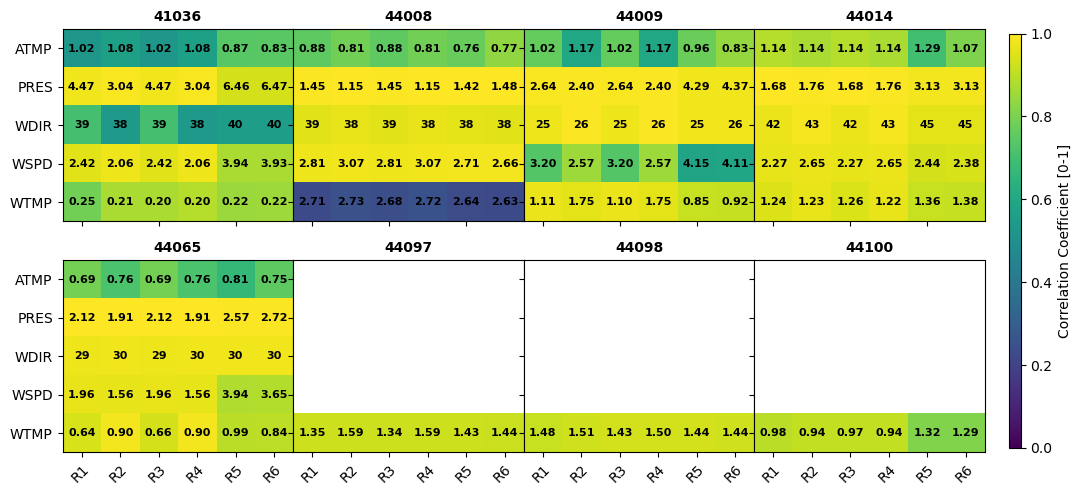

In [22]:
stations = ds_out.station.values
nstation = len(stations)

simulations = [ f'R{id+1}' for id in ds_out.simulation_id.values ]
vars = ds_out.variable.values

fig, ax = plt.subplots(2, nstation//2, figsize=(11.9,6), gridspec_kw={'wspace': 0.00, 'hspace': 0.00})
ax_flat = ax.flatten()

indx = 0
for s in ds_out.station:
    data_corr = ds_out.corr.sel(station=s)
    im = ax_flat[indx].imshow(data_corr, cmap="viridis", vmin=0, vmax=1)
    ax_flat[indx].set_xticklabels([])
    ax_flat[indx].set_xlabel('')
    ax_flat[indx].set_yticklabels([])
    ax_flat[indx].set_ylabel('')
    ax_flat[indx].set_title(s.values, fontsize=10, fontweight='bold')
    if indx > 3:
        ax_flat[indx].set_xticks(range(len(simulations)), labels=simulations, fontsize=10, rotation=45, ha="right", rotation_mode="anchor")
    if indx in [0, 4]:
        ax_flat[indx].set_yticks(range(len(vars)), labels=vars, fontsize=10)

    # Add RMSE
    j = 0
    for id in ds_out.simulation_id.values:
        i = 0
        for v in vars:
            data_rmse = ds_out.rmse.sel(station=s, simulation_id=id, variable=v)
            if not np.isnan(data_rmse):
                if v == 'WDIR':
                    text = ax_flat[indx].text(j, i, f'{data_rmse:.0f}', ha="center", va="center", fontweight='bold', fontsize=8, color="black")
                else:
                    text = ax_flat[indx].text(j, i, f'{data_rmse:.2f}', ha="center", va="center", fontweight='bold', fontsize=8, color="black")
            i=i+1
        j=j+1
        
    indx = indx+1

cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.69])
fig.colorbar(ax_flat[0].images[0], cax=cbar_ax, label='Correlation Coefficient [0-1]')

filename = "insitu_stats.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

In [11]:
# keep only radiation stations
keep_keys = {"44008", "44009"}
obs_loc_rad = {key: value for key, value in obs_loc.items() if key in keep_keys}

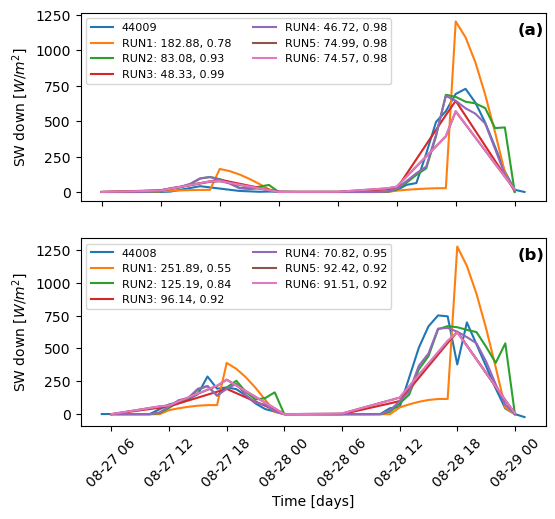

In [22]:
#fig, ax = plt.subplots(2, 1, figsize=(6,4.66))
#fig, ax = plt.subplots(1, 2, figsize=(12,2.78))
fig, ax = plt.subplots(2, 1, figsize=(6,5.36))
ax_flat = ax.flatten()
h1 = datetime.timedelta(hours=1)
x = pd.to_datetime(ds.ocean_time)
lowercase_letters = np.array(list(string.ascii_lowercase))

# First plot
#indx = 0

# Add ERA5
#x6 = x[::6]
#print(x6)
#ds_era5 = xr.open_dataset('era5/data_stream-oper_stepType-accum-interp.nc')
#data_era5 = ds_era5['ssr'].where(grid.mask_rho > 0).sel(time=x6).mean(dim=['eta_rho', 'xi_rho'])
#data_era5 = data_era5/3600.0
#data_era5 = data_era5.where(data_era5 >= 1.0e-5, other=0)
#ax_flat[indx].plot(x6, data_era5, label=f"ERA5")
#ax_flat[indx].set_xticklabels([])
#ax_flat[indx].set_xlabel('')

# Add experiments
#for id in ds.run_id.values:
#    data = ds['swrad'].where(grid.mask_rho > 0).isel(run_id=id).sel(ocean_time=x6).mean(dim=['eta_rho', 'xi_rho'])
#    data = data.where(data >= 1.0e-5, other=0)
#    print(f'RUN{id+1}')
    # Calculate RMSE and correlation
#    print(data)
#    print(data_era5)
    #rmse = np.sqrt(np.mean((data - data_era5).data ** 2))
    #corr = np.corrcoef(data, data_era5)[0, 1]
    #for i in range(len(data.values)):
    #    print(i, data.values[i], data_era5.values[i], np.sqrt(np.mean((data.values[i] - data_era5.values[i]) ** 2)))
    #ax_flat[indx].plot(x6, data, label=f'RUN{id+1}: {rmse:.2f}, {corr:.2f}')

# Add legend and y axis
#ax_flat[indx].legend(ncol=2, fontsize=8, loc="upper left")
#ax_flat[indx].set_ylabel(r'SW net [$W/m^2$]', fontsize=10)

# Second and third plot
indx = 0
for key, val in obs_loc_rad.items():    
    # Read in observation
    df = pd.read_csv(f'data/{key}r2011.txt', sep='\\s+', skiprows = [1])
    df.columns = df.columns.str.replace('#', '')
    df = df.rename(columns={'YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'})
    df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    time_mask = (df['Date']>= x[0]-h1) & (df['Date'] <= x[-1]+h1)
    df = df[time_mask]
    df = df.set_index(df['Date'])
    df['SRAD1'] = df['SRAD1'].where(df['SRAD1'] != 9999.0)
    df['SWRAD'] = df['SWRAD'].where(df['SWRAD'] != 9999.0)
    df['LWRAD'] = df['LWRAD'].where(df['LWRAD'] != 9999.0)

    # Plot observation, mask outliers or measurement errors
    var = 'SWRAD'
    all_nan = np.isnan(df[var]).all()
    if all_nan:
        var = 'SRAD1'
    ax_flat[indx].plot(df['Date'], df[var], label=f"{key}")

    # Perform temporal interpolation to simulation time to calculate statistics
    new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
    df_interp = df.reindex(new_index).interpolate(method='linear').resample('h').mean()[:-1]
    if df_interp[var].shape > ds.ocean_time.shape:
        df_interp = df_interp[1:]

    # Find closest grid point for model data
    points = np.vstack((grid.lat_rho.values.flatten(), grid.lon_rho.values.flatten())).T
    tree = KDTree(points)
    distance, index = tree.query([val[1], -1.0*val[0]])
    lat_index, lon_index = np.unravel_index(index, grid.lon_rho.shape)

    # Get model data and plot
    for id in ds.run_id.values:
        # Plot
        data = ds['swrad'].isel(run_id=id, eta_rho=lat_index, xi_rho=lon_index)
        # Calculate RMSE and correlation
        rmse = np.sqrt(np.mean((data - df_interp[var]).data ** 2))
        corr = np.corrcoef(data, df_interp[var])[0, 1]
        # Add label
        ax_flat[indx].plot(x, data, label=f'RUN{id+1}: {rmse:.2f}, {corr:.2f}')

    # Set x-axis
    ax_flat[indx].tick_params(axis='x', labelrotation=45)
    ax_flat[indx].set_xlabel('Time [days]', fontsize=10)
    if indx < 1: 
        ax_flat[indx].set_xticklabels([])
        ax_flat[indx].set_xlabel('')

    # Set y-axis
    ax_flat[indx].set_ylabel(r'SW down [$W/m^2$]', fontsize=10)

    # Add label
    ax_flat[indx].legend(ncol=2, fontsize=8, loc='upper left')

    # Add label
    ax_flat[indx].text(0.94, 0.95, f'({lowercase_letters[indx]})', fontsize=12, fontweight='bold', verticalalignment='top', transform=ax_flat[indx].transAxes)

    indx = indx+1

filename = "insitu_swrad.png"
#plt.tight_layout(pad=0.0)
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

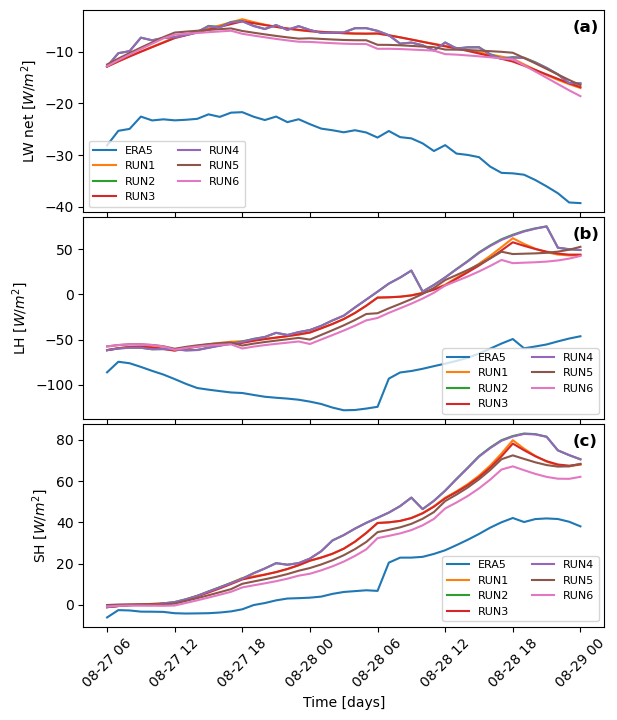

In [56]:
nrow = 3
ncol = 1
fig, ax = plt.subplots(nrow, ncol, figsize=(6,7))
ax_flat = ax.flatten()
x = pd.date_range("2011-08-27T06:00:00", "2011-08-29T00:00:00", freq="1h")

var_list = {
    'lwrad': ['W/m2', 'LW net', 'Longwave Radiation', 'lower left'],
    'latent': ['W/m2', 'LH', 'Latent Heat Flux', 'lower right'],
    'sensible': ['W/m2', 'SH', 'Sensible Heat Flux', 'lower right'],
}

# Add ERA5
ds_era5 = xr.open_dataset('era5/1h/data_stream-oper_stepType-accum-interp.nc')

indx = 0
for v in ['str', 'slhf', 'sshf']:
    data = ds_era5[f"{v}"].where(grid.mask_rho > 0).sel(time=x).mean(dim=['eta_rho', 'xi_rho'])
    data = data/3600.0
    #if v in ['slhf', 'sshf']:
    #    data = -1.0*data
    ax_flat[indx].plot(x, data, label=f"ERA5")
    indx = indx+1

# Add model results
indx = 0
for v in var_list.keys():
    for id in ds.run_id.values:
        data = ds[f"{v}"].where(grid.mask_rho > 0).isel(run_id=id).mean(dim=['eta_rho', 'xi_rho'])
        ax_flat[indx].plot(x, data, label=f"RUN{id+1}")

    if indx > 1:
        ax_flat[indx].set_xlabel('Time [days]')
    else:
        ax_flat[indx].set_xticklabels([])
        ax_flat[indx].set_xlabel('')
    ax_flat[indx].tick_params(axis='x', labelrotation=45)
    
    ax_flat[indx].legend(ncol=2, fontsize=8, loc=var_list[f'{v}'][3])
    vn = var_list[f'{v}'][1]
    ax_flat[indx].set_ylabel(fr'{vn} [$W/m^2$]', fontsize=10)
        
    # Add label
    ax_flat[indx].text(0.94, 0.95, f'({lowercase_letters[indx]})', fontsize=12, fontweight='bold', verticalalignment='top', transform=ax_flat[indx].transAxes)
    
    indx = indx+1

# Save figure
plt.tight_layout(pad=0.0)
fig.savefig(f"flux_comparison.png", bbox_inches='tight', pad_inches=0.6, dpi=300)

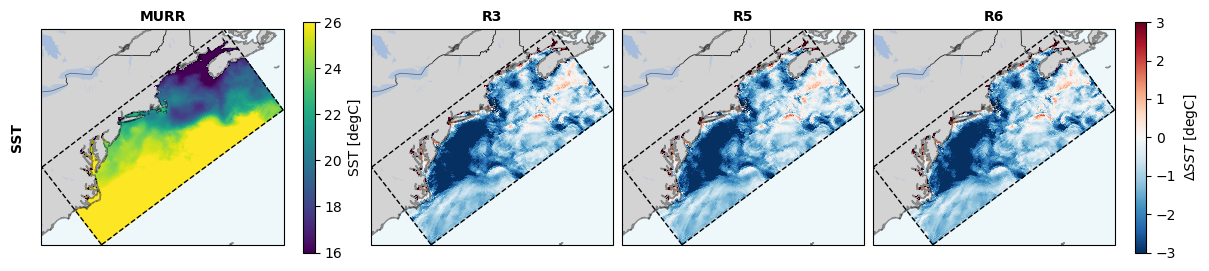

In [29]:
# Load observation
ds_obs = xr.open_dataset("sst_murr_2011-08-21_2011-08-30_remap.nc")
data_obs = ds_obs.analysed_sst-273.15

# Dimensions
lats = ds["lat_rho"]
lons = ds["lon_rho"]

# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Plot data
fig, ax = plt.subplots(1, 4,
    figsize=(12, 5.7), 
    layout='constrained', 
    subplot_kw={'projection': projection})
ax_list = ax.flatten().tolist()

vmin, vmax = vars["temp"]

# Plot observation, 3 day average
data_obs_mean = data_obs.isel(time=[5, 6, 7]).mean(dim=['time'])
im0 = ax_list[0].pcolormesh(lons, lats, data_obs_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax_list[0].set_title('MURR', fontweight='bold', fontsize=10)
add_features(ax_list[0], stock_img=False)
add_roms_box(ax_list[0], grid)
fig.colorbar(im0, ax=ax_list[0], pad=0.08, aspect=20, shrink=0.41, label='SST [degC]')
ax_list[0].text(-0.1, 0.5, "SST", transform=ax_list[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

# Loop over runs
indx = 1
for id in ds.run_id.values:
    if id in [2,4,5]:
        # Plot data
        data_model_mean = ds['temp'].isel(run_id=id).resample(ocean_time='1D').mean(dim=['ocean_time'])
        data_model_mean = data_model_mean.mean(dim=['ocean_time'])
        data_diff = data_model_mean-data_obs_mean
        im1 = ax_list[indx].pcolormesh(lons, lats, data_diff, shading='auto', cmap='RdBu_r', vmin=-3, vmax=3, transform=ccrs.PlateCarree())
        ax_list[indx].set_title(f'R{id+1}', fontweight='bold', fontsize=10)

        # Add map features
        add_features(ax_list[indx], stock_img=False)

        # Add domain box
        add_roms_box(ax_list[indx], grid)

        # Add color bar
        if indx == 3:
            fig.colorbar(im1, ax=ax_list[indx], pad=0.08, aspect=20, shrink=0.41, label=r'$\Delta SST$ [degC]')

        indx = indx+1

filename = "spatial_sst.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

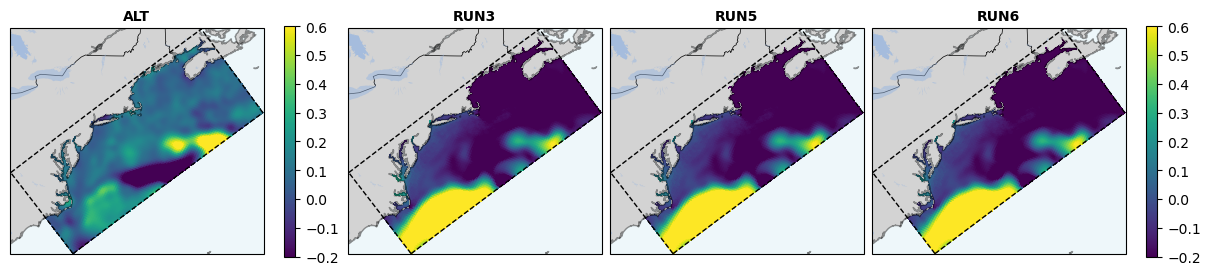

In [66]:
# Plot data
fig, ax = plt.subplots(1, 4,
    figsize=(12, 5.7), 
    layout='constrained', 
    subplot_kw={'projection': projection})
ax_list = ax.flatten().tolist()

vmin, vmax = vars["zeta"]

# Load observation
ds_obs = xr.open_dataset("dt_global_allsat_phy_l4_remap.nc")

# Plot observation, 3 day average
#data_obs_mean = (ds_obs.adt - ds_obs.sla).mean(dim=['time'])
data_obs_mean = ds_obs.sla.mean(dim=['time'])
#data_obs_mean = ds_obs.adt.mean(dim=['time']) - ds_obs.adt.mean(dim=['eta_rho', 'xi_rho'])
#data_obs_mean = ds_obs.adt - ds_obs.adt.mean(dim=['eta_rho', 'xi_rho'])
#data_obs_mean = data_obs_mean.mean(dim=['time'])
im0 = ax_list[0].pcolormesh(lons, lats, data_obs_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax_list[0].set_title('ALT', fontweight='bold', fontsize=10)
add_features(ax_list[0], stock_img=False)
add_roms_box(ax_list[0], grid)
fig.colorbar(im0, ax=ax_list[0], pad=0.08, aspect=20, shrink=0.41, label='')

# Loop over runs
indx = 1
for id in ds.run_id.values:
    if id in [2,4,5]:
        # Plot data
        #data_model_mean = ds['zeta'].isel(run_id=id).resample(ocean_time='1D').mean(dim=['ocean_time'])
        #data_model_mean = data_model_mean.mean(dim=['ocean_time'])
        #data_diff = data_model_mean-data_obs_mean
        #data = ds['zeta'].isel(run_id=id)-ds['zeta'].isel(run_id=id).mean(dim=['ocean_time'])
        #data = data.mean(dim=['ocean_time'])
        #data_diff = data#-data_obs_mean
        #data_diff = ds['zeta'].isel(run_id=id).mean(dim=['ocean_time'])
        #im1 = ax_list[indx].pcolormesh(lons, lats, data_diff, shading='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5, transform=ccrs.PlateCarree())

        #data_model_mean = ds['zeta'].isel(run_id=id)-ds['zeta'].isel(run_id=id).mean(dim=['eta_rho', 'xi_rho'])
        #data_model_mean = data_model_mean.mean(dim=['ocean_time'])
        im1 = ax_list[indx].pcolormesh(lons, lats, data_model_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
        ax_list[indx].set_title(f'RUN{id+1}', fontweight='bold', fontsize=10)

        # Add map features
        add_features(ax_list[indx], stock_img=False)

        # Add domain box
        add_roms_box(ax_list[indx], grid)

        # Add color bar
        if indx == 3:
            fig.colorbar(im1, ax=ax_list[indx], pad=0.08, aspect=20, shrink=0.41, label='')

        indx = indx+1

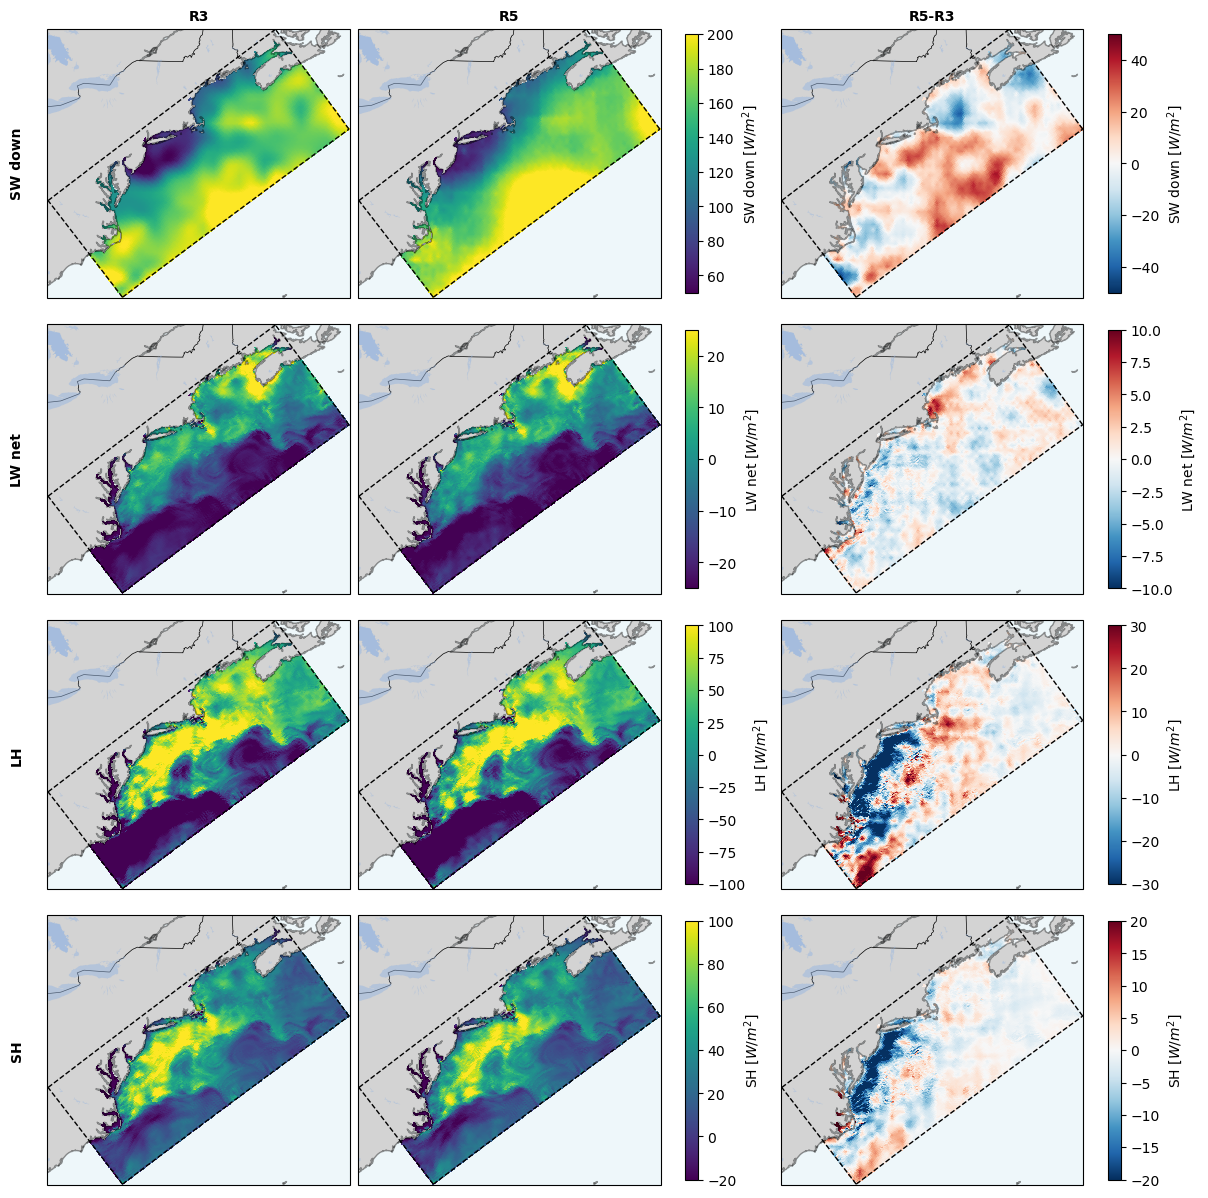

In [69]:
# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

var_list = {
    'swrad': ['W/m2', 'SW down', 'Shortwave Radiation'],
    'lwrad': ['W/m2', 'LW net', 'Longwave Radiation'],
    'latent': ['W/m2', 'LH', 'Latent Heat Flux'],
    'sensible': ['W/m2', 'SH', 'Sensible Heat Flux'],
}

diff_range = {
    'Pair': [-2.5, 2.5],
    'Tair': [-1, 1],
    'Uwind': [-2, 2],
    'Vwind': [-2, 2],
    'swrad': [-50, 50],
    'lwrad': [-10, 10],
    'latent': [-30, 30],
    'sensible': [-20, 20],
    'temp': [-0.5, 0.5],
    'zeta' : [-0.05, 0.05]
}

# Create figure
nrow = 4
ncol = 3
fig, ax = plt.subplots(
    nrow, 
    ncol, 
    figsize=(12, 12), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Add plot
time_str = "2011-08-27T12:00:00"

i = 0
for v in var_list.keys():
    irow = i
    vmin, vmax = vars[f"{v}"]

    data3 =  ds[f"{v}"].isel(run_id=2).mean(dim=['ocean_time'])
    im1 = ax[irow,0].pcolormesh(ds.lon_rho, ds.lat_rho, data3, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    
    data5 =  ds[f"{v}"].isel(run_id=4).mean(dim=['ocean_time'])
    im2 = ax[irow,1].pcolormesh(ds.lon_rho, ds.lat_rho, data5, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    fig.colorbar(im2, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=fr'{var_list[f'{v}'][1]} [$W/m^2$]')

    if False:
        xskip = 4
        yskip = 4
        scale = 200
        lon = ds.lon_rho.values[::yskip,::xskip]
        lat = ds.lat_rho.values[::yskip,::xskip]
        datau =  ds.Uwind.isel(run_id=2).mean(dim=['ocean_time']).values[::yskip,::xskip]
        datav =  ds.Vwind.isel(run_id=2).mean(dim=['ocean_time']).values[::yskip,::xskip]
        q1 = ax[irow,0].quiver(lon, lat, datau, datav, scale=scale, transform=ccrs.PlateCarree())

        datau =  ds.Uwind.isel(run_id=4).mean(dim=['ocean_time']).values[::yskip,::xskip]
        datav =  ds.Vwind.isel(run_id=4).mean(dim=['ocean_time']).values[::yskip,::xskip]
        q2 = ax[irow,1].quiver(lon, lat, datau, datav, scale=scale, transform=ccrs.PlateCarree())

    diff = data5-data3
    vmin, vmax = diff_range[f"{v}"]
    im3 = ax[irow,2].pcolormesh(ds.lon_rho, ds.lat_rho, diff, shading='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    fig.colorbar(im3, ax=ax[irow,2], pad=0.08, aspect=20, shrink=0.9, label=fr'{var_list[f'{v}'][1]} [$W/m^2$]')

    if irow == 0:
        ax[irow,0].set_title('R3', fontweight='bold', fontsize=10)
        ax[irow,1].set_title('R5', fontweight='bold', fontsize=10)
        ax[irow,2].set_title('R5-R3', fontweight='bold', fontsize=10)
    else:
        for icol in range(0, 3):
            ax[irow,icol].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{var_list[f'{v}'][1]}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    # Add map features
    for icol in range(0, 3):
        add_features(ax[irow,icol], stock_img=False)

    # Add ROMS grid box
    for icol in range(0, 3):
        add_roms_box(ax[irow,icol], grid)

    i = i+1

filename = "spatial_flux.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)